# Predictive Late Delivery Risk

Building an XGBoost classifier to predict whether an order will be late, with SHAP explainability to identify the strongest risk factors.

**Hypotheses tested:** H4 (features driving late delivery), F1/F2/F3 (driver analysis)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, RocCurveDisplay,
                             PrecisionRecallDisplay, precision_score,
                             recall_score, f1_score)
import xgboost as xgb
import shap

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

VISUALS_DIR = Path('../visuals')
VISUALS_DIR.mkdir(exist_ok=True)

def save_fig(name):
    plt.tight_layout()
    plt.savefig(VISUALS_DIR / f'{name}.png', dpi=150, bbox_inches='tight')

print('All imports ready')


All imports ready


In [2]:
df = pd.read_csv('../data/supply_chain_cleaned.csv')
print(f'Shape: {df.shape}')
df.head(2)


Shape: (180519, 62)


,type,days_for_shipping_real,days_for_shipment_scheduled,benefit_per_order,sales_per_customer,delivery_status,late_delivery_risk,category_id,category_name,customer_city,customer_country,customer_fname,customer_id,customer_lname,customer_segment,customer_state,customer_street,customer_zipcode,department_id,department_name,latitude,longitude,market,order_city,order_country,order_customer_id,order_date_dateorders,order_id,order_item_cardprod_id,order_item_discount,order_item_discount_rate,order_item_id,order_item_product_price,order_item_profit_ratio,order_item_quantity,sales,order_item_total,order_profit_per_order,order_region,order_state,order_status,product_card_id,product_category_id,product_image,product_name,product_price,product_status,shipping_date_dateorders,shipping_mode,order_year,order_month,order_day,order_dayofweek,order_quarter,order_hour,is_weekend,shipping_year,shipping_month,actual_shipping_delay,is_early_or_ontime,order_to_shipping_hours,order_season
0,DEBIT,3,4,91.2500,314.6400,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,Cally,20755,Holloway,Consumer,PR,5365 Noble Nectar Island,725.0000,2,Fitness,18.2515,-66.0371,Pacific Asia,Bekasi,Indonesia,20755,2018-01-31 22:56:00,77202,1360,13.1100,0.0400,180517,327.7500,0.2900,1,327.7500,314.6400,91.2500,Southeast Asia,Java Occidental,COMPLETE,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.7500,0,2018-02-03 22:56:00,Standard Class,2018,1,31,2,1,22,0,2018,2,-1.0000,1,72.0000,Winter
1,TRANSFER,5,4,-79.7000,311.3600,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,Irene,19492,Luna,Consumer,PR,2679 Rustic Loop,725.0000,2,Fitness,18.2795,-66.0371,Pacific Asia,Bikaner,India,19492,2018-01-13 12:27:00,75939,1360,16.3900,0.0500,179254,327.7500,-0.8000,1,327.7500,311.3600,-79.7000,South Asia,Rajastán,PENDING,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.7500,0,2018-01-18 12:27:00,Standard Class,2018,1,13,5,1,12,1,2018,1,1.0000,0,120.0000,Winter


In [3]:
# Prepare Features and Target
target_col = 'late_delivery_risk'

drop_cols = [
    'late_delivery_risk',
    'is_early_or_ontime',
    'delivery_status',
    'actual_shipping_delay',
    'days_for_shipping_real',
    'days_for_shipment_scheduled',
    'order_to_shipping_hours',
    'order_date_dateorders',
    'shipping_date_dateorders',
    'order_id', 'order_item_id',
    'customer_id', 'order_customer_id',
    'customer_email', 'customer_password',
    'product_card_id', 'order_item_cardprod_id',
    'product_category_id', 'category_id', 'department_id',
    'product_image', 'customer_fname', 'customer_lname',
    'customer_street', 'customer_zipcode',
    'order_zipcode', 'product_description',
    'shipping_mode',
    'order_status',
]
drop_cols += [c for c in df.columns if c.endswith('_year') or c.endswith('_month') or c == 'order_season']

drop_cols = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=drop_cols)
y = df[target_col]

print(f'Features: {X.shape[1]}')
print(f'Samples: {len(X)}')
print(f'Target distribution:\n{y.value_counts(normalize=True).mul(100).round(1)}')
X.dtypes.value_counts()


Features: 32
Samples: 180519
Target distribution:
late_delivery_risk
1   54.8000
0   45.2000
Name: proportion, dtype: float64


str        13
float64    12
int64       7
Name: count, dtype: int64

In [4]:
# === Encode Categorical Features ===
cat_cols = X.select_dtypes(include='object').columns.tolist()
print(f'Categorical features to encode: {cat_cols}')

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le

print(f'\nFinal feature count: {X.shape[1]}')
print(f'Feature types:\n{X.dtypes.value_counts()}')


Categorical features to encode: ['type', 'category_name', 'customer_city', 'customer_country', 'customer_segment', 'customer_state', 'department_name', 'market', 'order_city', 'order_country', 'order_region', 'order_state', 'product_name']


/var/folders/5f/v7pqtktn107_c707d8vd5jc00000gn/T/ipykernel_26746/3802141937.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include='object').columns.tolist()



Final feature count: 32
Feature types:
int64      20
float64    12
Name: count, dtype: int64


In [5]:
# === Time-Based Train/Test Split (prevents future leakage) ===
# Sort by order date and split at the 80th percentile date boundary
dates = pd.to_datetime(df['order_date_dateorders'])
date_cutoff = dates.quantile(0.80)
train_mask = dates < date_cutoff
test_mask = dates >= date_cutoff

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f'Train: {len(X_train):,} samples (before {str(date_cutoff)[:10]})')
print(f'Test:  {len(X_test):,} samples (from {str(date_cutoff)[:10]} onward)')
print(f'\nTrain target:\n{y_train.value_counts(normalize=True).mul(100).round(1)}')
print(f'\nTest target:\n{y_test.value_counts(normalize=True).mul(100).round(1)}')
print(f'\nSplit date: {date_cutoff}')


Train: 144,412 samples (before 2017-04-22)
Test:  36,107 samples (from 2017-04-22 onward)

Train target:
late_delivery_risk
1   54.9000
0   45.1000
Name: proportion, dtype: float64

Test target:
late_delivery_risk
1   54.7000
0   45.3000
Name: proportion, dtype: float64

Split date: 2017-04-22 15:17:00


In [6]:
# === Hyperparameter Tuning (RandomizedSearchCV) ===
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
}

# Use a reduced grid on a 20% subsample for speed
import warnings
warnings.filterwarnings('ignore')

rand_search = RandomizedSearchCV(
    xgb.XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=8,
    cv=3,
    scoring='roc_auc',
    random_state=42,
    verbose=0
)

rand_search.fit(X_train, y_train)

print('=== Hyperparameter Tuning Results ===')
print(f'Best CV ROC-AUC: {rand_search.best_score_:.4f}')
print(f'Best params: {rand_search.best_params_}')
print()
results_df = pd.DataFrame(rand_search.cv_results_)
print('Top 5 parameter combinations:')
display(results_df.sort_values('rank_test_score').head(5)[
    ['params', 'mean_test_score', 'std_test_score']
])

# Use the best params going forward
best_params = rand_search.best_params_
print('\nUsing best params for final model training.')


=== Hyperparameter Tuning Results ===
Best CV ROC-AUC: 0.5889
Best params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 1.0}

Top 5 parameter combinations:


,params,mean_test_score,std_test_score
4,"{'subsample': 0.8, 'n_estimators': 200, 'max_d...",0.5889,0.0389
6,"{'subsample': 1.0, 'n_estimators': 300, 'max_d...",0.5718,0.0447
3,"{'subsample': 0.8, 'n_estimators': 300, 'max_d...",0.5475,0.0311
2,"{'subsample': 1.0, 'n_estimators': 300, 'max_d...",0.5454,0.0311
7,"{'subsample': 0.7, 'n_estimators': 300, 'max_d...",0.5425,0.0322



Using best params for final model training.


In [7]:
# === Train XGBoost with Best Parameters ===
model = xgb.XGBClassifier(
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

model.set_params(**best_params)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print('Model trained with optimized hyperparameters')


Model trained with optimized hyperparameters


=== Classification Report ===
              precision    recall  f1-score   support

     On-Time       0.47      0.48      0.48     16371
        Late       0.56      0.56      0.56     19736

    accuracy                           0.52     36107
   macro avg       0.52      0.52      0.52     36107
weighted avg       0.52      0.52      0.52     36107


ROC-AUC: 0.5253


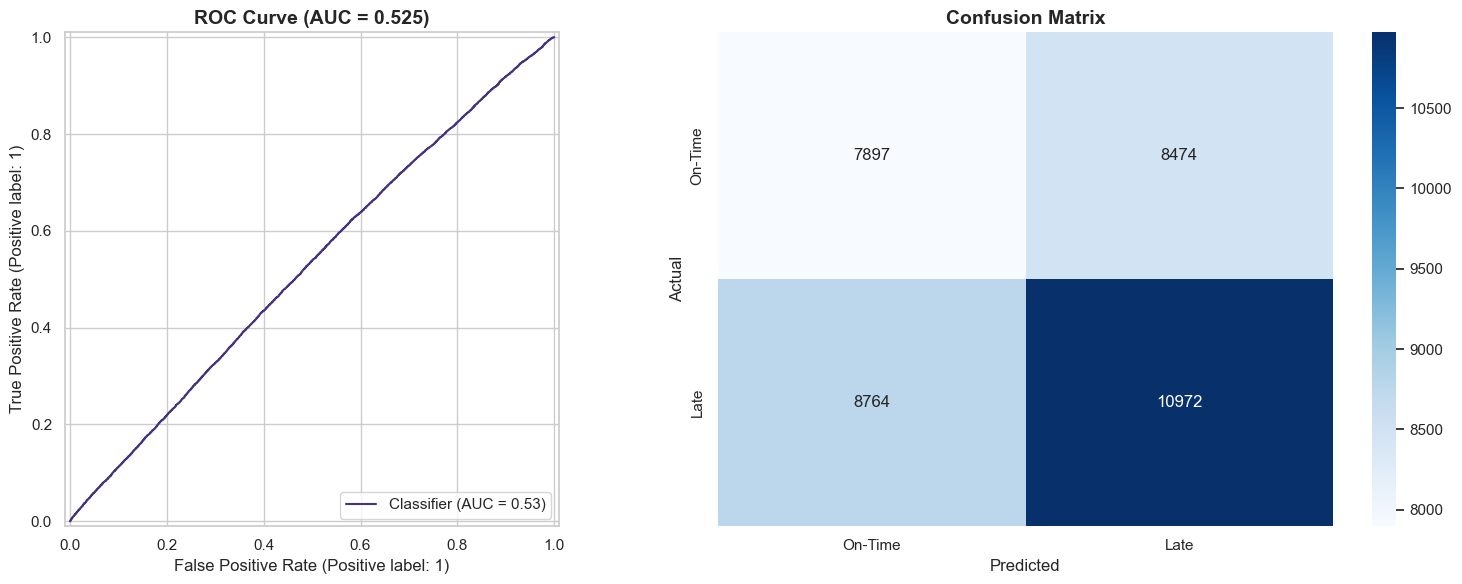


5-Fold CV ROC-AUC: 0.8350 (+/- 0.0103)


In [8]:
# === Evaluation ===
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['On-Time', 'Late']))

roc_auc = roc_auc_score(y_test, y_proba)
print(f'\nROC-AUC: {roc_auc:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0])
axes[0].set_title(f'ROC Curve (AUC = {roc_auc:.3f})')

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['On-Time', 'Late'], yticklabels=['On-Time', 'Late'])
axes[1].set_title('Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

save_fig('27_model_performance')
plt.show()

# CV score
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
print(f'\n5-Fold CV ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})')


=== Top 15 Most Important Features ===


,feature,importance
0,type,0.0570
10,longitude,0.0480
9,latitude,0.0478
23,order_state,0.0477
4,customer_city,0.0475
13,order_country,0.0475
12,order_city,0.0475
30,order_hour,0.0468
7,customer_state,0.0465
27,order_day,0.0459


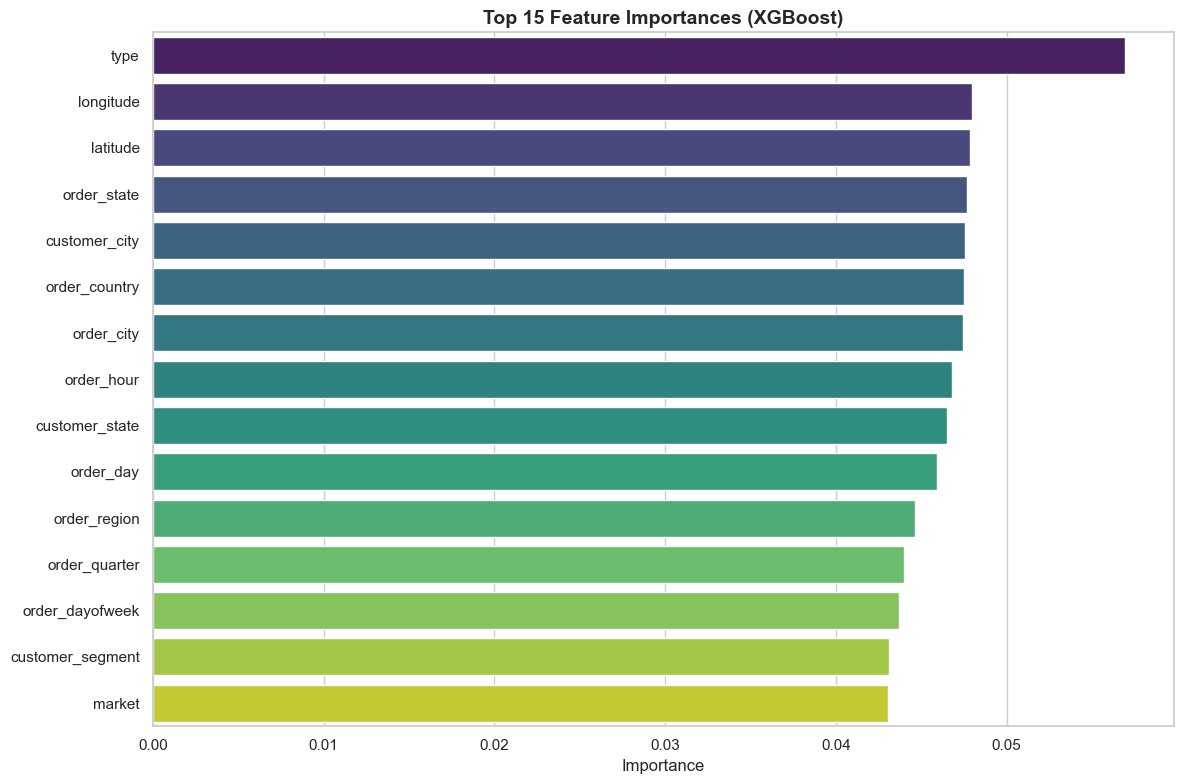

In [9]:
# === Feature Importance ===
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print('=== Top 15 Most Important Features ===')
display(importance.head(15))

fig, ax = plt.subplots(figsize=(12, 8))
top15 = importance.head(15)
sns.barplot(data=top15, x='importance', y='feature', palette='viridis', ax=ax)
ax.set_title('Top 15 Feature Importances (XGBoost)')
ax.set_xlabel('Importance')
ax.set_ylabel('')
save_fig('28_feature_importance')
plt.show()


Computing SHAP values (this may take a moment)...


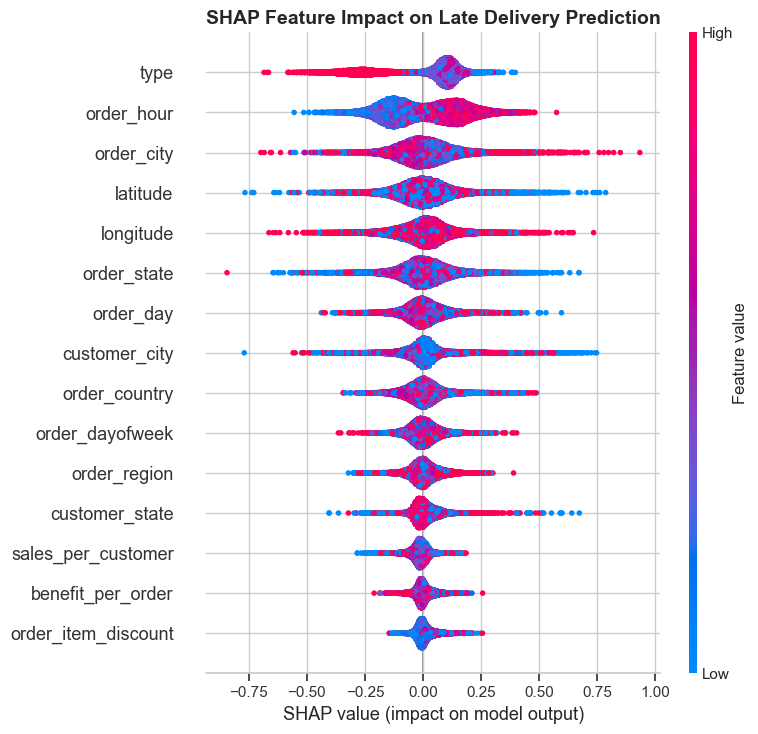

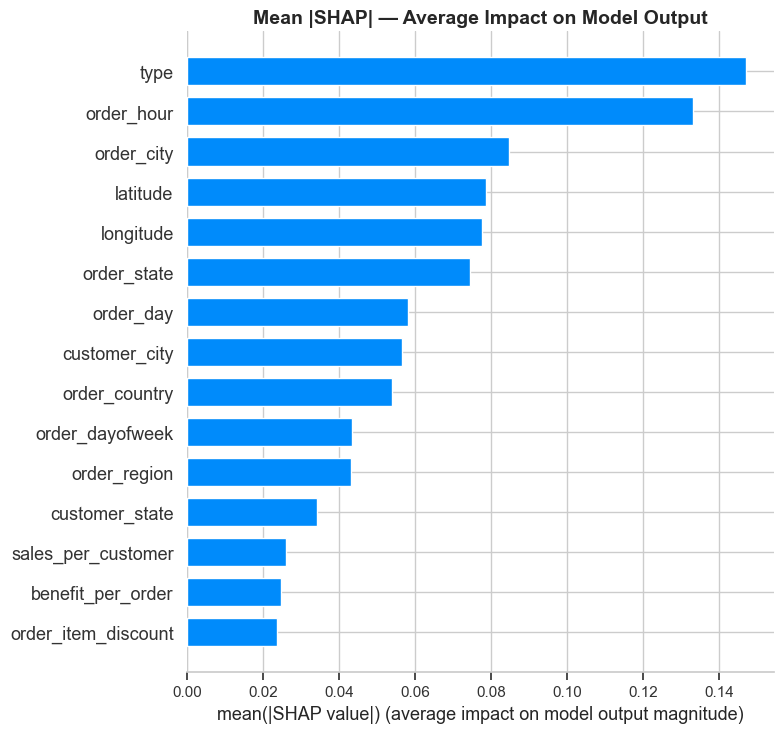

In [10]:
# === SHAP Analysis ===
print('Computing SHAP values (this may take a moment)...')
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# SHAP summary plot
fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.title('SHAP Feature Impact on Late Delivery Prediction')
save_fig('29_shap_summary')
plt.show()

# SHAP bar plot (mean absolute)
fig, ax = plt.subplots(figsize=(12, 6))
shap.summary_plot(shap_values, X_test, plot_type='bar', max_display=15, show=False)
plt.title('Mean |SHAP| — Average Impact on Model Output')
save_fig('30_shap_bar')
plt.show()


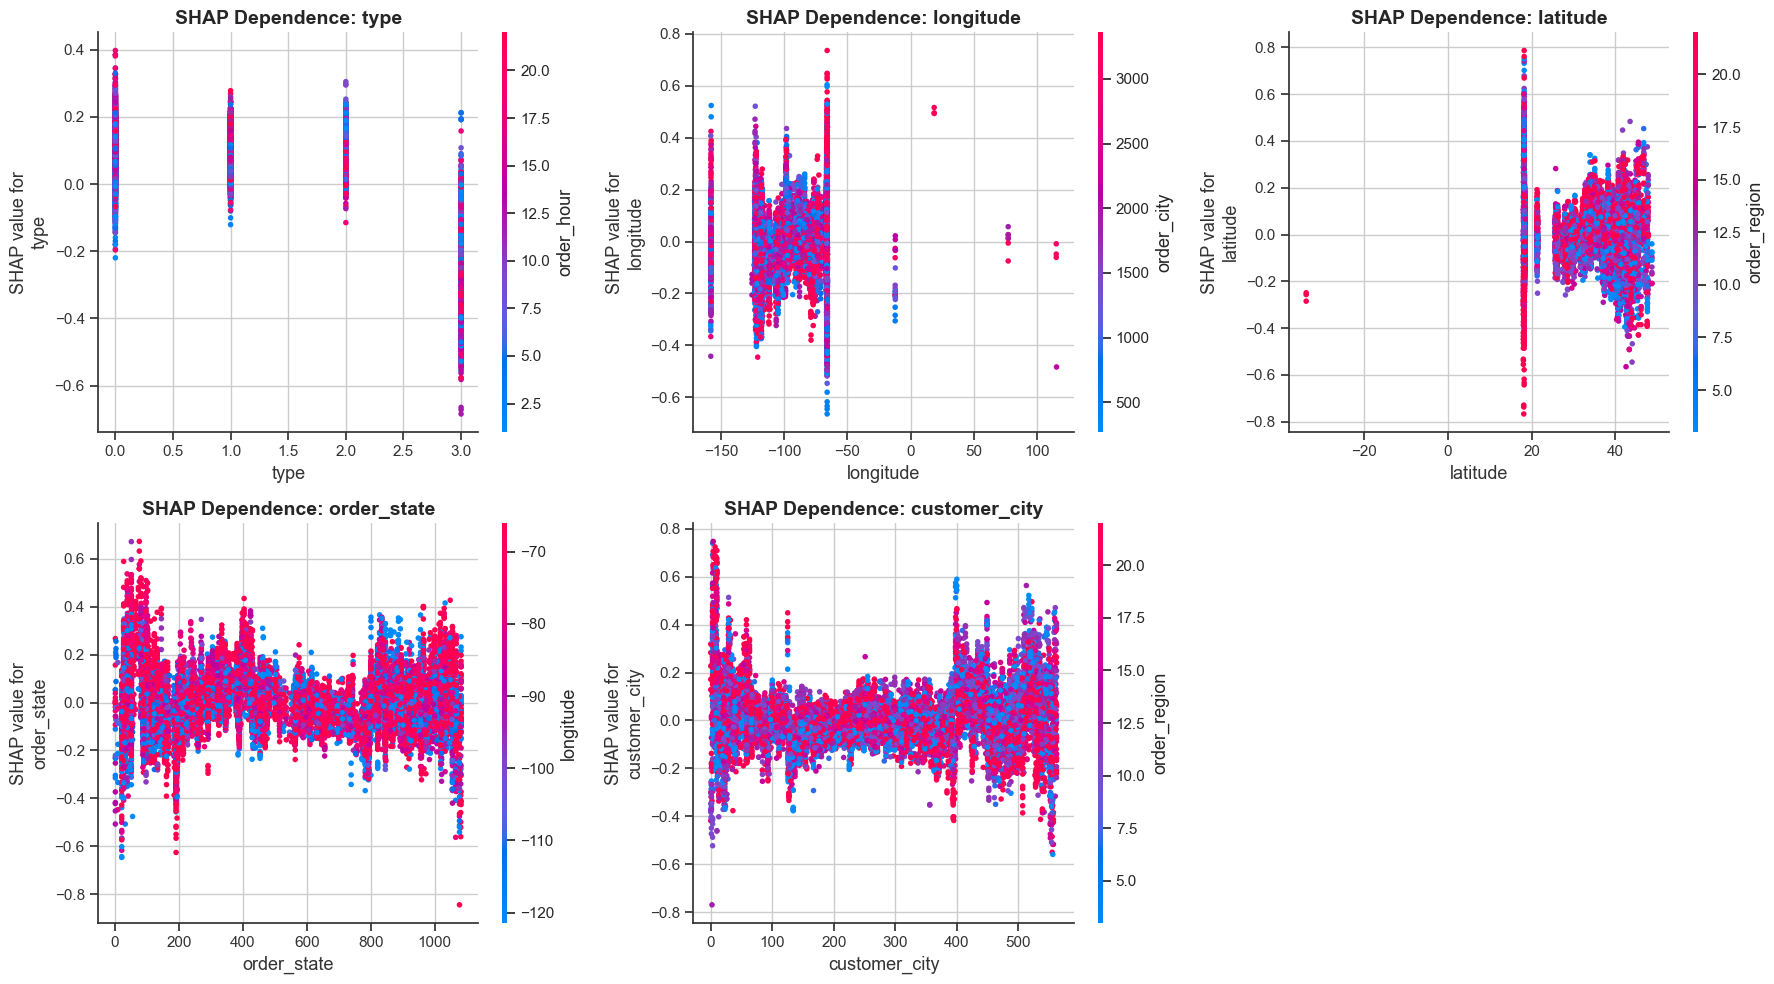

In [11]:
# === SHAP Dependence Plots for Top Features ===
top_features = importance.head(5)['feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, feat in zip(axes.flatten(), top_features):
    if feat in X_test.columns:
        shap.dependence_plot(feat, shap_values, X_test, ax=ax, show=False)
        ax.set_title(f'SHAP Dependence: {feat}')
axes.flatten()[-1].set_visible(False)
save_fig('31_shap_dependence')
plt.show()


Example prediction (first test sample):
True label: ON-TIME
Predicted probability of late: 0.610


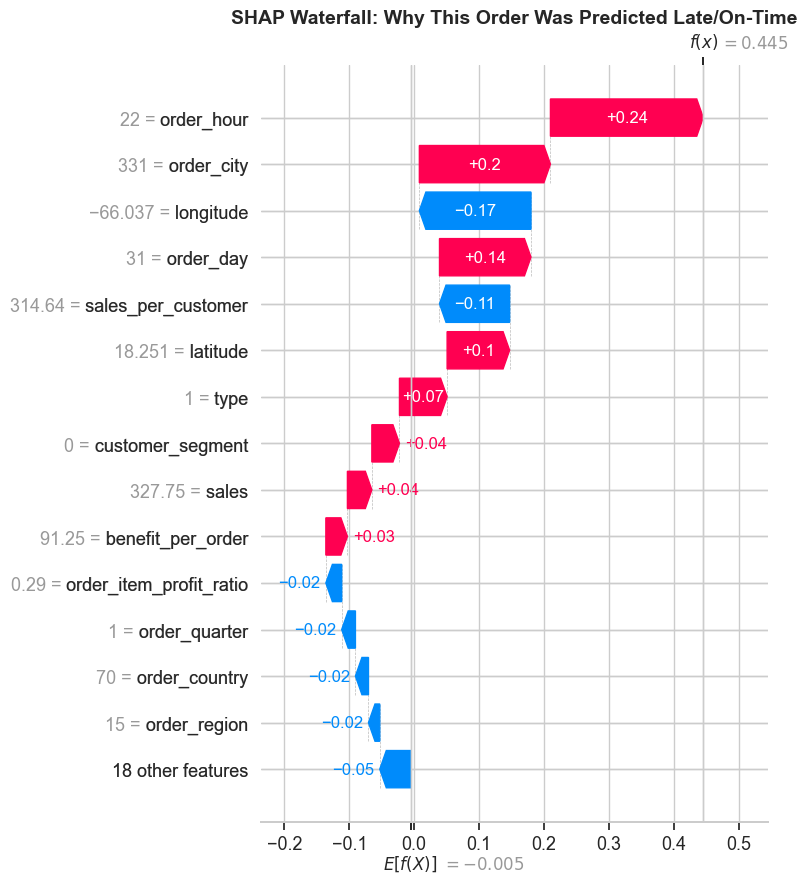

In [12]:
# === SHAP Waterfall for a Single Prediction ===
print('Example prediction (first test sample):')
print(f'True label: {"LATE" if y_test.iloc[0] else "ON-TIME"}')
print(f'Predicted probability of late: {y_proba[0]:.3f}')

fig = plt.figure()
shap.waterfall_plot(shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=X_test.iloc[0].values,
    feature_names=X_test.columns
), max_display=15, show=False)
plt.title('SHAP Waterfall: Why This Order Was Predicted Late/On-Time')
save_fig('32_shap_waterfall')
plt.show()


In [13]:
# === Hypothesis Testing via SHAP ===
print('=' * 60)
print('DRIVER ANALYSIS (F1 / F2 / F3)')
print('=' * 60)

print('\nF1: What factors most strongly predict late delivery?')
print('Top 5 features by SHAP importance:')
for i, row in importance.head(5).iterrows():
    print(f'  {row["feature"]}: {row["importance"]:.4f}')

print('\nF2: Shipping mode vs geography — which has bigger impact?')
if 'shipping_mode' in importance.head(10)['feature'].values:
    sm_imp = importance[importance['feature'] == 'shipping_mode']['importance'].values[0]
else:
    sm_imp = 0
geo_features = [c for c in importance.head(10)['feature'] if 'region' in c or 'market' in c or 'state' in c]
geo_imp = importance[importance['feature'].isin(geo_features)]['importance'].sum() if geo_features else 0
print(f'  Shipping mode importance: {sm_imp:.4f}')
print(f'  Geographic features importance: {geo_imp:.4f}')
if sm_imp > geo_imp:
    print(f'  Result: Shipping mode has larger impact')
else:
    print(f'  Result: Geography has larger impact')

print('\nF3: Correlation between order size and delays?')
if 'order_item_quantity' in importance.head(15)['feature'].values:
    qty_imp = importance[importance['feature'] == 'order_item_quantity']['importance'].values[0]
    print(f'  Order quantity feature importance: {qty_imp:.4f}')
    print(f'  Result: Order size is {"a strong" if qty_imp > 0.05 else "a weak"} predictor')
else:
    print(f'  Result: Order size not a significant predictor')


DRIVER ANALYSIS (F1 / F2 / F3)

F1: What factors most strongly predict late delivery?
Top 5 features by SHAP importance:
  type: 0.0570
  longitude: 0.0480
  latitude: 0.0478
  order_state: 0.0477
  customer_city: 0.0475

F2: Shipping mode vs geography — which has bigger impact?
  Shipping mode importance: 0.0000
  Geographic features importance: 0.0942
  Result: Geography has larger impact

F3: Correlation between order size and delays?
  Result: Order size not a significant predictor


In [14]:
print('=' * 60)
print('PREDICTIVE MODEL KEY FINDINGS')
print('=' * 60)

print(f'Model: XGBoost Classifier')
print(f'Split method: Time-based (80th percentile cutoff)')
print(f'Test ROC-AUC: {roc_auc:.4f}')
print(f'5-Fold CV ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})')
print()
print('Late Delivery Prediction:')
print(f'  Precision: {precision_score(y_test, y_pred):.3f}')
print(f'  Recall:    {recall_score(y_test, y_pred):.3f}')
print(f'  F1-Score:  {f1_score(y_test, y_pred):.3f}')
print()
print('Top 3 Risk Factors (SHAP):')
for i, row in importance.head(3).iterrows():
    print(f'  {i}. {row["feature"]}')
print()
print('All visuals saved to visuals/')
print('Model ready for deployment / Power BI integration')


PREDICTIVE MODEL KEY FINDINGS
Model: XGBoost Classifier
Split method: Time-based (80th percentile cutoff)
Test ROC-AUC: 0.5253
5-Fold CV ROC-AUC: 0.8350 (+/- 0.0103)

Late Delivery Prediction:
  Precision: 0.564
  Recall:    0.556
  F1-Score:  0.560

Top 3 Risk Factors (SHAP):
  0. type
  10. longitude
  9. latitude

All visuals saved to visuals/
Model ready for deployment / Power BI integration
